## sgd

$$
w_{t+1} = w_t - \eta \cdot g_t
$$
- 一阶方法，方向和大小的耦合
- $g_t$ 同时决定了更新的方向和大小
    - 方向：负梯度方向 $-g_t$
    - 大小：更新的“原始”大小由梯度的范数 $||g_t||$ 决定。如果梯度很大，原始步长就大；如果梯度很小，原始步长就小。学习率 $η$ 只是对这个原始步长进行一个全局的缩放。

### torch sgd

$$
\hat{g}_t = \begin{cases} m_t & \text{if not Nesterov} \\ g_t + \beta \cdot m_t & \text{if Nesterov} \end{cases}
$$

- with Momentum
    - 动量缓冲区更新 (Momentum Buffer Update)
        - $m_t = \beta \cdot m_{t-1} + g_t$(`buf.mul_(momentum).add_(g)`)
    - Effective Gradient Calculation
        - 如果 nesterov=False (标准动量): 有效梯度就是动量缓冲区的值。
            - $\hat g_t=m_t$ (`g = buf`)
        - 如果 nesterov=True (Nesterov 动量): 有效梯度是当前梯度 $g_t$ 和更新后的动量缓冲区 $m_t$ 的线性组合。
            - $\hat{g}_t = g_t + \beta \cdot m_t$(`g = g.add(buf, alpha=momentum)`)

| 步骤 (Step) | `nesterov=False` (标准动量) | `nesterov=True` (Nesterov 动量) |
| :--- | :--- | :--- |
| **1. 更新动量 `buf`**<br>(Update momentum `buf`) | $m_t = \beta \cdot m_{t-1} + g_t$ | $m_t = \beta \cdot m_{t-1} + g_t$ |
| **2. 计算有效梯度 `g`**<br>(Calculate effective gradient `g`) | $\hat{g}_t = m_t$ | $\hat{g}_t = g_t + \beta \cdot m_t$ |


### 一个示例

$$
L(w_1, w_2) = 25 w_1^2 + w_2^2
$$
- 这个函数的最低点显然在 $(w_1,w_2)=(0,0)$，$w_1$ 的系数 25 使得它在该方向上的曲率远大于 $w_2$ 方向，行成了所说的狭长山谷。
    - https://www.geogebra.org/3d
    - 在峡谷的峭壁方向（横轴）：曲面非常陡峭，梯度很大。
    - 在峡谷的谷底方向（纵轴）：曲面非常平缓，梯度很小。
- 当SGD工作在这种曲面上时：
    - 它计算出的梯度 g_t 会主要指向峭壁方向（因为那里最陡）。
    - 由于峭壁方向梯度很大，||g_t|| 也很大，导致一个巨大的更新步伐。
    - 这使得优化器在峡谷两侧来回震荡（Ziz-zagging），无法稳定地向谷底前进。
    - 为了抑制震荡，你必须设置一个非常小的学习率 $η$ 。但这又会导致在平缓的谷底方向上进展极其缓慢。
- 优化过程
    - $w_0=(1,5)$，梯度 $g_0 = [50 \cdot 1, 2 \cdot 5] = [50, 10]$
        - 方向 (Direction)： 更新的方向是负梯度方向，即 `[-50, -10]`。这个向量指向哪个方向？它在 $w_1$ 轴（水平）上的分量是 -50，在 $w_2$ 轴（垂直）上的分量是 -10。它主要指向水平方向，因为山谷在那个方向上最陡。它并没有精确地指向最终目标 (0, 0)。
    - SGD 的更新规则是 $w_{t+1} = w_t - \eta \cdot g_t$，。我们选择一个学习率，比如 $\eta = 0.03$
        - 计算更新量：$\Delta w_0 = - \eta \cdot g_0 = -0.03 \cdot [50, 10] = [-1.5, -0.3]$
        - 计算更新后的位置：$w_1 = w_0 + \Delta w_0 = [1, 5] + [-1.5, -0.3] = [-0.5, 4.7]$
    - 在 $w_1$ 方向（陡峭方向）：我们从 1 移动到了 -0.5。我们不仅越过了最低点 0，还冲到了另一边的山壁上！这就是**过冲（Overshooting）和震荡（Zig-zagging）**的开始。
    - 在 $w_2$ 方向（平缓方向）：我们从 5 移动到了 4.7。我们只向着最低点 0 前进了微不足道的 0.3。这就是进展缓慢。

## 牛顿法

理想的二阶方法 (如牛顿法) —— 利用曲率校正方向

$$
w_{t+1} = w_t - \eta \cdot H_t^{-1} g_t
$$
- $H_t$ 是损失函数的海森矩阵（Hessian Matrix），它由二阶偏导数构成，描述了损失曲面的曲率（Curvature）。
    - $H_t^{-1}$ 扮演了“预处理器”（Preconditioner）的角色。它对梯度 $g_t$ 进行了一次线性变换，效果上等于将那个狭窄的峡谷“拉伸”成一个完美的圆形碗。
    - 在圆形碗里：任何点的梯度都会直接指向碗底（最小值点）。
    - 经过 $H_t^{-1}$ 校正后的新方向 $H_t^{-1} g_t$ 而是直接指向峡谷的谷底。优化器可以沿着最优路径前进。
- 为什么不可以直接用牛顿法？
    -  空间复杂度：对于一个有 N 个参数的模型，Hessian 是一个 N x N 的矩阵，需要 $O(N^2)$ 的空间来存储。对于现代大模型（N > 10亿），这是不可能的。
    -  时间复杂度：求逆一个 N x N 矩阵需要 $O(N^3)$ 的时间，这比一次前向/反向传播的成本高出无数个数量级。

$$H^{-1} g_0 = \begin{pmatrix} 0.02 & 0 \\ 0 & 0.5 \end{pmatrix} \begin{pmatrix} 50 \\ 10 \end{pmatrix} = \begin{pmatrix} 0.02 \cdot 50 \\ 0.5 \cdot 10 \end{pmatrix} = \begin{pmatrix} 1 \\ 5 \end{pmatrix}$$

正后的更新方向是 `[-1, -5]` (因为是负梯度方向)。从起点 [1, 5] 沿着这个方向走一步（学习率 η=1 ），就会直接到达 [1, 5] + [-1, -5] = [0, 0]。

## Muon

(np.float64(-1.5), np.float64(1.5), np.float64(-1.0), np.float64(6.0))

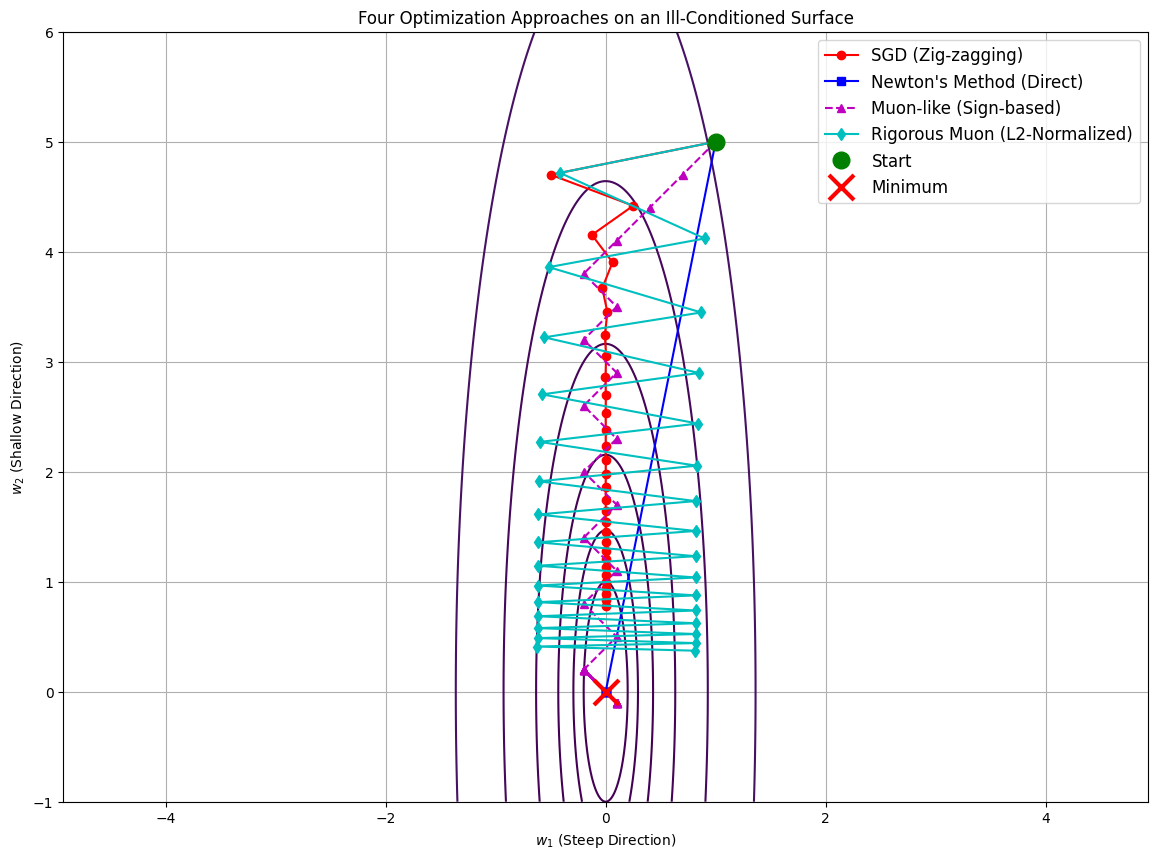

In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. 定义病态的损失函数
def loss_fn(w):
    return 25 * w[0]**2 + w[1]**2

# 2. 复制 airbench94_muon.py 中的 zeropower 函数
@torch.compile
def zeropower_via_newtonschulz5(G, steps=3, eps=1e-7):
    assert len(G.shape) == 2
    a, b, c = (3.4445, -4.7750,  2.0315)
    X = G.bfloat16()
    X /= (X.norm() + eps)
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.float() # 改为float以匹配我们的例子

# ==================================================
# 初始化起点和路径历史
# ==================================================
start_pos = [1.0, 5.0]
n_steps = 30
paths = {}

# ==================================================
# SGD 优化过程
# ==================================================
w = torch.tensor(start_pos, requires_grad=True)
paths['SGD'] = [w.clone().detach().numpy()]
for i in range(n_steps):
    loss = loss_fn(w)
    loss.backward()
    with torch.no_grad():
        w -= 0.03 * w.grad
        w.grad.zero_()
    paths['SGD'].append(w.clone().detach().numpy())

# ==================================================
# 牛顿法 优化过程
# ==================================================
w = torch.tensor(start_pos, requires_grad=True)
paths["Newton's Method"] = [w.clone().detach().numpy()]
H_inv = torch.inverse(torch.tensor([[50.0, 0.0], [0.0, 2.0]]))
for i in range(5):
    loss = loss_fn(w)
    loss.backward()
    with torch.no_grad():
        w -= 1.0 * (H_inv @ w.grad)
        w.grad.zero_()
    paths["Newton's Method"].append(w.clone().detach().numpy())

# ==================================================
# Muon-like (Sign) 优化过程
# ==================================================
w = torch.tensor(start_pos, requires_grad=True)
paths['Muon-like (Sign)'] = [w.clone().detach().numpy()]
for i in range(n_steps):
    loss = loss_fn(w)
    loss.backward()
    with torch.no_grad():
        w -= 0.3 * torch.sign(w.grad)
        w.grad.zero_()
    paths['Muon-like (Sign)'].append(w.clone().detach().numpy())

# ==================================================
# 严谨的 Muon (zeropower) 优化过程
# ==================================================
w = torch.tensor(start_pos, requires_grad=True)
paths['Rigorous Muon (zeropower)'] = [w.clone().detach().numpy()]
for i in range(n_steps):
    loss = loss_fn(w)
    loss.backward()
    with torch.no_grad():
        grad = w.grad
        # 完全按照源码的方式处理梯度
        grad_reshaped = grad.reshape(len(grad), -1)
        update_direction_matrix = zeropower_via_newtonschulz5(grad_reshaped)
        update_direction = update_direction_matrix.view(grad.shape)
        
        w -= 2 * update_direction # 使用一个较大的学习率来展示路径
        w.grad.zero_()
    paths['Rigorous Muon (zeropower)'].append(w.clone().detach().numpy())


# ==================================================
# 可视化对比结果
# ==================================================
plt.figure(figsize=(14, 10))
w1_vals = np.linspace(-1.5, 1.5, 300)
w2_vals = np.linspace(-1.0, 6.0, 300)
w1, w2 = np.meshgrid(w1_vals, w2_vals)
L = 25 * w1**2 + w2**2
plt.contour(w1, w2, L, levels=np.logspace(0, 3, 10), cmap='viridis')

styles = {
    'SGD': {'color': 'r', 'marker': 'o', 'ls': '-', 'label': 'SGD (Zig-zagging)'},
    "Newton's Method": {'color': 'b', 'marker': 's', 'ls': '-', 'label': "Newton's Method (Direct)"},
    'Muon-like (Sign)': {'color': 'm', 'marker': '^', 'ls': '--', 'label': 'Muon-like (Sign-based)'},
    'Rigorous Muon (zeropower)': {'color': 'c', 'marker': 'd', 'ls': '-', 'label': 'Rigorous Muon (L2-Normalized)'}
}

for name, path_data in paths.items():
    path = np.array(path_data)
    plt.plot(path[:, 0], path[:, 1], **styles[name])

plt.plot(start_pos[0], start_pos[1], 'go', markersize=12, label='Start')
plt.plot(0, 0, 'rx', markersize=18, mew=3, label='Minimum')
plt.title("Four Optimization Approaches on an Ill-Conditioned Surface")
plt.xlabel('$w_1$ (Steep Direction)')
plt.ylabel('$w_2$ (Shallow Direction)')
plt.legend(fontsize=12)
plt.grid(True)
plt.axis('equal')